In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

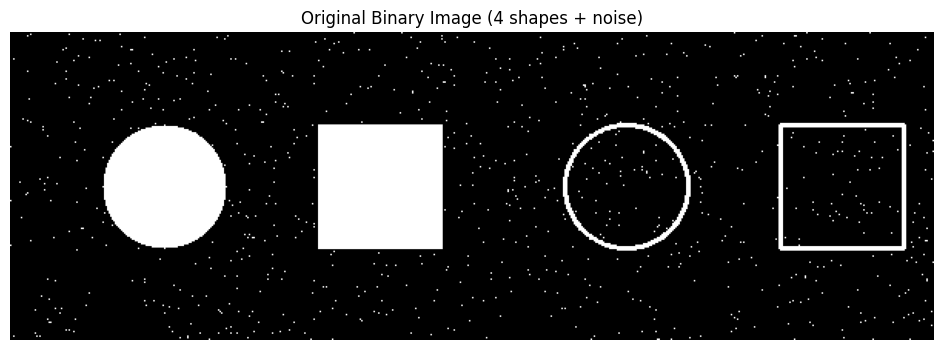

In [3]:
image = np.zeros((200, 600), dtype=np.uint8)
cv2.circle(image, (100, 100), 40, 255, -1)
cv2.rectangle(image, (200, 60), (280, 140), 255, -1)
cv2.circle(image, (400, 100), 40, 255, 2)
cv2.rectangle(image, (500, 60), (580, 140), 255, 2)

np.random.seed(0)
for _ in range(1000):
    x, y = np.random.randint(0, 600), np.random.randint(0, 200)
    image[y, x] = 255

plt.figure(figsize=(12, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Binary Image (4 shapes + noise)')
plt.axis('off')
plt.show()

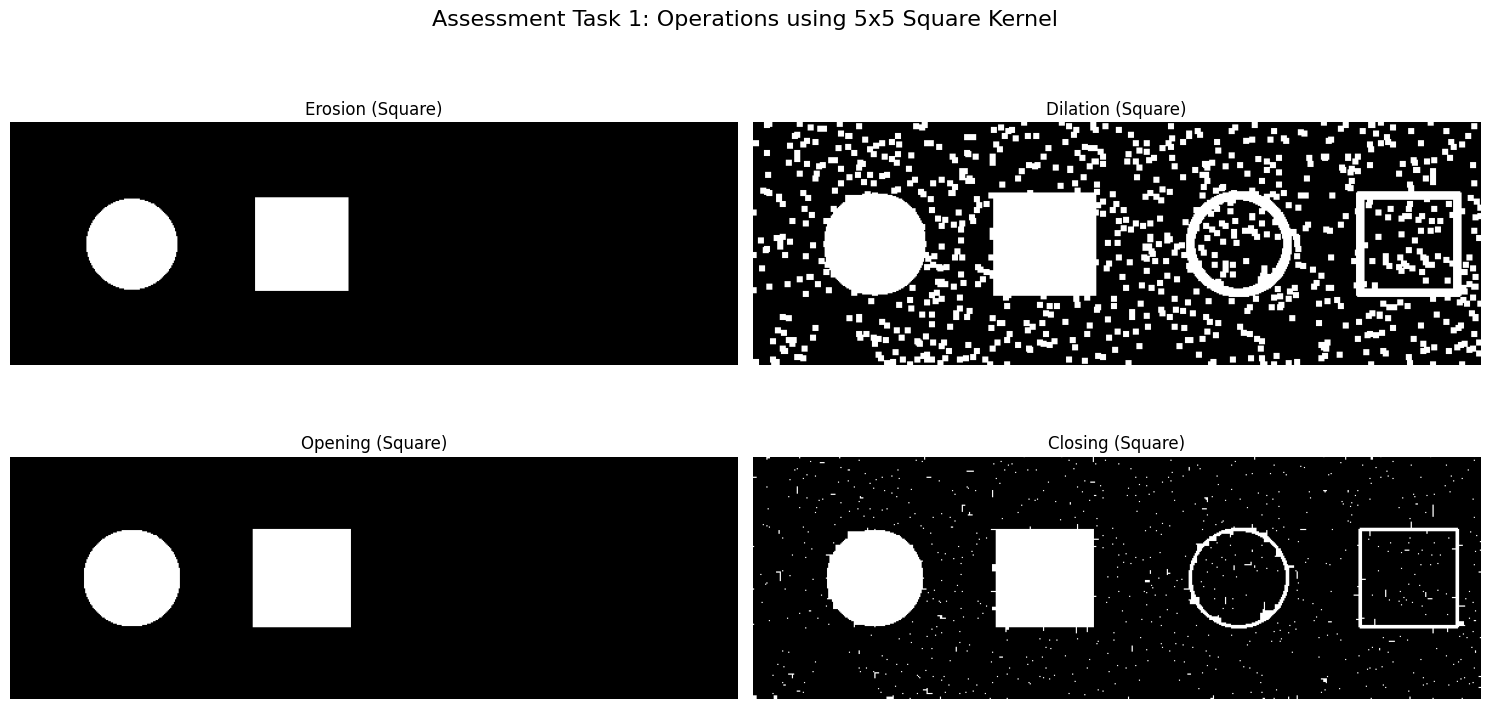

In [4]:
square_kernel = np.ones((5, 5), np.uint8)

erosion_sq = cv2.erode(image, square_kernel, iterations=1)
dilation_sq = cv2.dilate(image, square_kernel, iterations=1)
opening_sq = cv2.morphologyEx(image, cv2.MORPH_OPEN, square_kernel)
closing_sq = cv2.morphologyEx(image, cv2.MORPH_CLOSE, square_kernel)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Assessment Task 1: Operations using 5x5 Square Kernel', fontsize=16)

axes[0, 0].imshow(erosion_sq, cmap='gray')
axes[0, 0].set_title('Erosion (Square)')
axes[0, 0].axis('off')

axes[0, 1].imshow(dilation_sq, cmap='gray')
axes[0, 1].set_title('Dilation (Square)')
axes[0, 1].axis('off')

axes[1, 0].imshow(opening_sq, cmap='gray')
axes[1, 0].set_title('Opening (Square)')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing_sq, cmap='gray')
axes[1, 1].set_title('Closing (Square)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

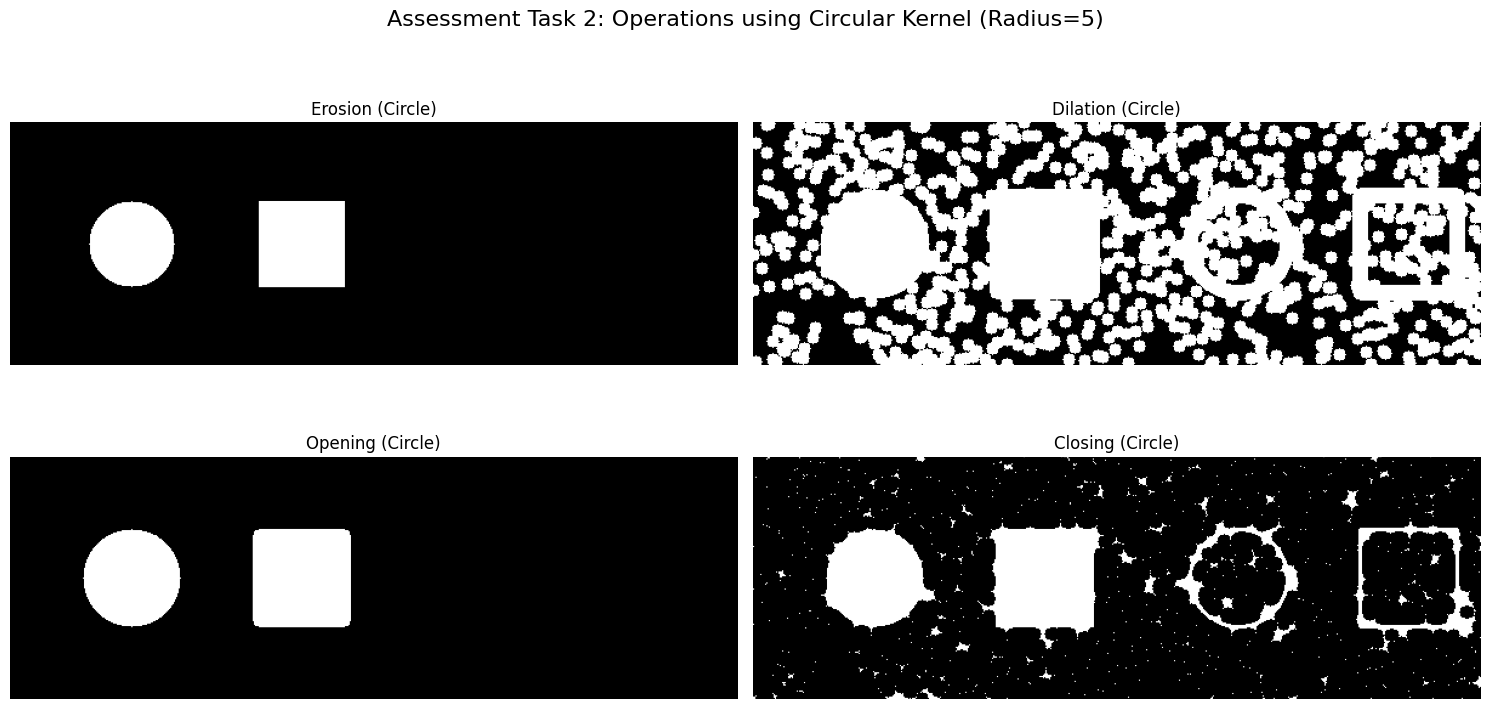

In [5]:
def circular_structuring_element(radius):
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(kernel, (radius, radius), radius, 1, -1)
    return kernel

radius = 5
circle_kernel = circular_structuring_element(radius)

erosion_cir = cv2.erode(image, circle_kernel, iterations=1)
dilation_cir = cv2.dilate(image, circle_kernel, iterations=1)
opening_cir = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closing_cir = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Assessment Task 2: Operations using Circular Kernel (Radius=5)', fontsize=16)

axes[0, 0].imshow(erosion_cir, cmap='gray')
axes[0, 0].set_title('Erosion (Circle)')
axes[0, 0].axis('off')

axes[0, 1].imshow(dilation_cir, cmap='gray')
axes[0, 1].set_title('Dilation (Circle)')
axes[0, 1].axis('off')

axes[1, 0].imshow(opening_cir, cmap='gray')
axes[1, 0].set_title('Opening (Circle)')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing_cir, cmap='gray')
axes[1, 1].set_title('Closing (Circle)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()